In [1]:
import sys
import os
sys.path.append("../../../src/")

sys.path.append("equilibrium_critical_correlation_data/")
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.pyplot import yscale, xscale, plot, scatter, loglog, ylim, xlim, title, legend

In [2]:
correlator_data=[]
for n in range(1,10):

    path = "connected_correlations/"
    file_name = f"corr_connected_n0{n}_r00-200.npy"

    correlator_data.append(np.load(path+file_name))

correlator_data = np.array(correlator_data)

label_list = [f"n = {n}" for n in range(1,len(correlator_data)+1)]

r = np.arange(0,len(correlator_data[0]))

# Basic Plot

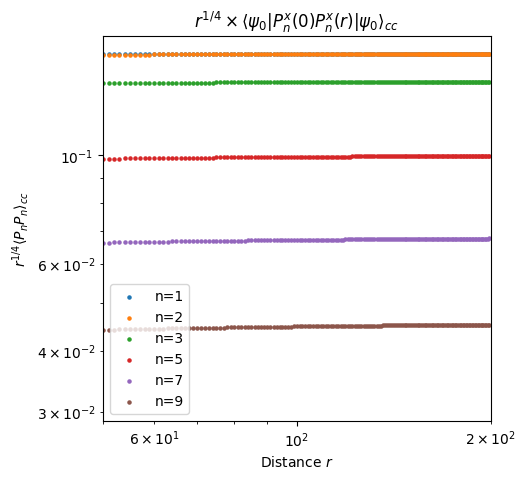

In [3]:
plt.figure(figsize=(5,5))  # width = 6 inches, height = 6 inches
from math import comb

y = correlator_data[0]
for i,x in enumerate(correlator_data):
    if i%2==1 and i!=1:
        continue
    n= i+1
    b= 0
    rescaled = x*r**(1/4)
    scatter(r,rescaled,label=f"n={n}",s=5)
xlim([50,200])
#plot(r,r**(-2.)/6,ls="--",color="black",label=r"$r^{-1/4}$")
#ylim([0.00000001,1])
plt.title(r"$r^{1/4} \times \langle \psi_0 |P^x_n(0) P^x_n(r)| \psi_0  \rangle_{cc}$"
)
plt.xlabel(r"Distance $r$")
plt.ylabel(r"$r^{1/4}\langle P_n P_n \rangle_{cc}$")

plt.yscale("log")
plt.xscale("log")
legend()
#plt.savefig("rescaled_connected_correlation_functions")


# Calculation of $c_n$

In [4]:
def cn(n, Rs=(400, 500, 600)):
    idx0 = list(range(n))
    vals = []
    for R in Rs:
        num = sigma_general(idx0 + [R + n - 1])   # ⟨σ_0…σ_{n-1} σ_R⟩
        den = sigma_general([0, R])               # ⟨σ_0 σ_R⟩
        vals.append(num / den)                    # → c_n as R→∞
    return float(np.mean(vals))


cn(3)

NameError: name 'sigma_general' is not defined

In [386]:
from equilibrium_critical_correlations import P_n, sigma_general, P_n_correlations, Dn

def cn(n):
    c1 = sigma_general([0,200])

    indices = [i for i in range(0,n)]+[200+n-1]
    
   # print(indices)
    return sigma_general(indices)/c1

In [390]:
13.835/16

0.8646875

In [388]:
(9+6*cn(3)+cn(3)*cn(3))/16

np.float64(0.8784703932072611)

In [394]:
def cc(n):
    x = np.array([comb(n,2*i+1)*cn(2*i+1) for i in range(n//2+1)])
    print(x)
    return np.sum(x)**2

cc(3)-13.835

[3.         0.74907006]


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


np.float64(0.22052629131617785)

In [248]:
def PnPn(n,r):
    pf= cc(n)/4**(n)*sigma_general([0,1])

    return pf*r**(-1/4)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22613/2549714565.py:4: RuntimeWarning: divide by zero encountered in power
  return pf*r**(-1/4)


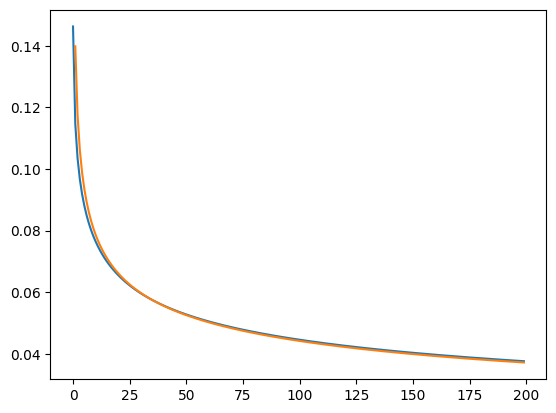

In [258]:
dat= PnPn(3,r)
plot(r,correlator_data[2,:])
plot(r,dat)

In [143]:
from scipy.optimize import curve_fit
def power_law(x,A,B):
    return A*x**B
def exp_law(x,A,B,C):
    return A*np.exp(-B*x)+C







def fit(dat,X):
    params_power_law , cov_power_law = curve_fit(power_law, X, dat)
    #a_power_law, b_power_law = params_power_law
    params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)
    plt.scatter(X,dat)
    plt.loglog(X,power_law(X,*params_power_law),label=f"powerlaw, b = {str(params_power_law[1])[:6]}")
    #plt.loglog(X,exp_law(X,*params_exp_law),label=f"exp law, b = {str(params_exp_law[1])[:5]}")
    plt.legend()
    plt.xlim(X[0],X[-1])
    #plt.ylim(0,1)
    #plt.show()
    print(params_power_law[0])
    print(params_power_law[1])
    #print(np.sqrt(np.diag(cov_exp_law)))
    return params_power_law


0.1612497817952911
-0.24999910130215097


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22613/777126130.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)


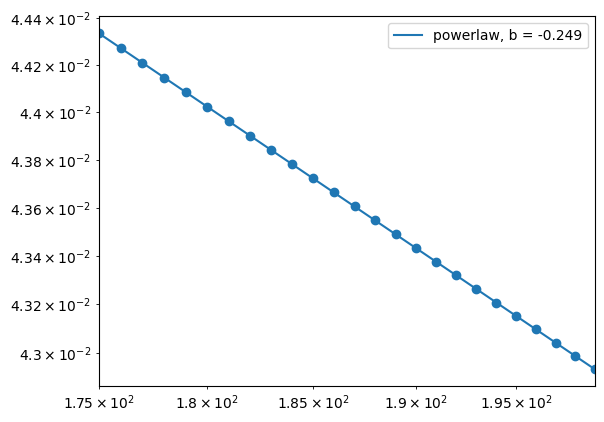

0.15992657175878036
-0.24867780527548655


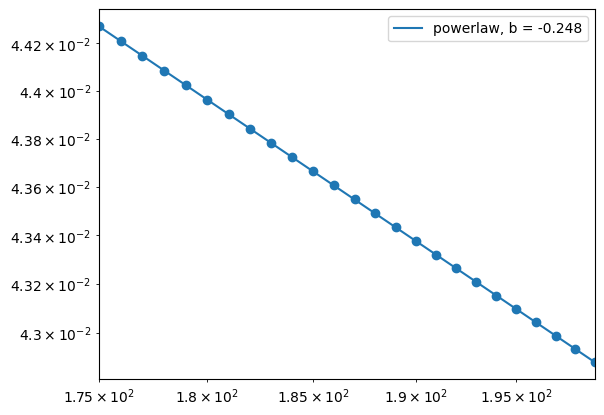

0.1394338354447593
-0.24738986343247607


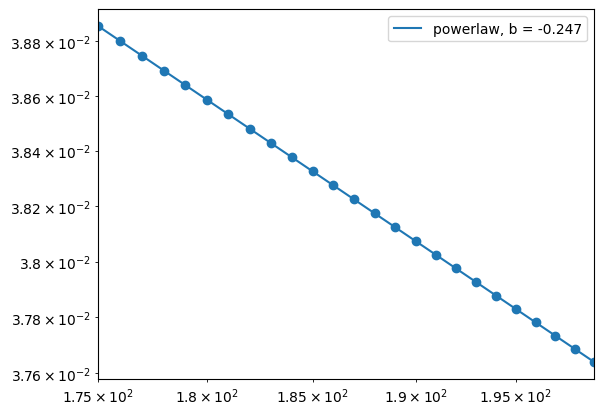

0.117304236203357
-0.24613324206818127


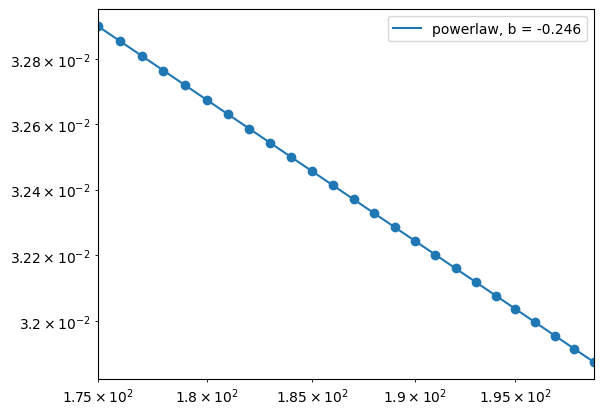

0.09713338686524232
-0.24490615125881612


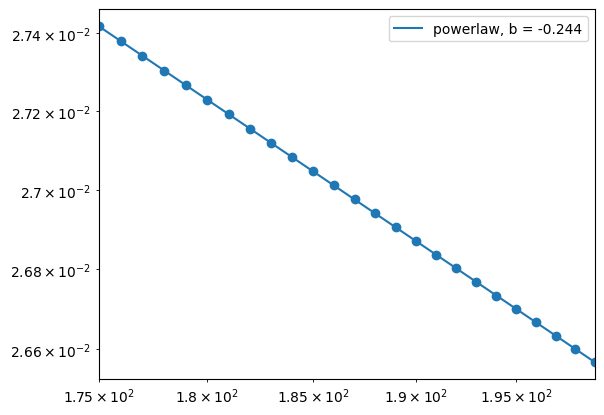

0.07972780279743805
-0.24370707519095564


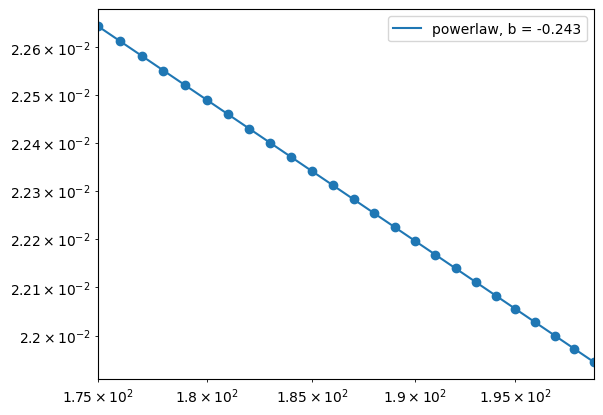

0.0650816126160162
-0.24253469697579746


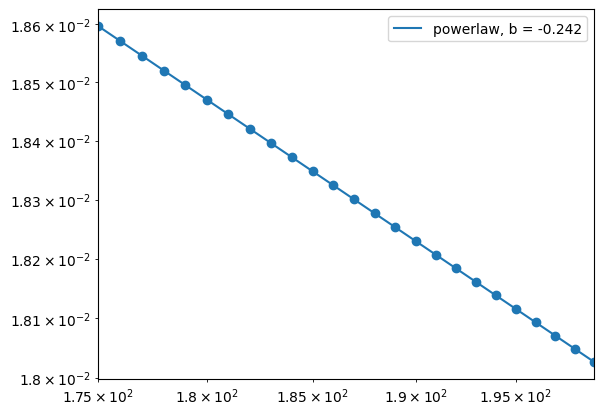

0.0529272505043236
-0.24138784589761783


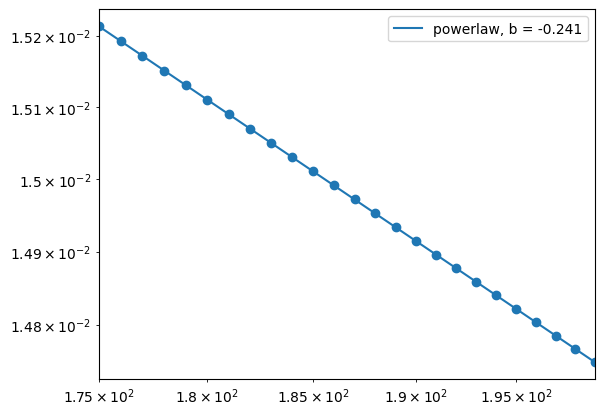

0.04292691415825366
-0.24026546364588197


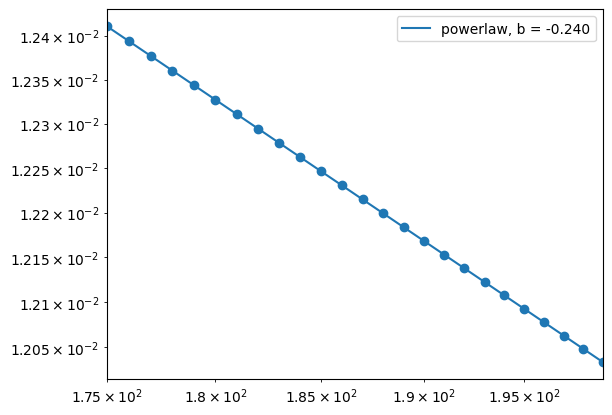

In [268]:
dat= []
for i,x in enumerate(correlator_data):
   n=i+1
   dat+=[fit(x[175:],r[175:])]
   plt.show()

[1.         0.99179404 0.86470713 0.72746912 0.60237841 0.49443666
 0.40360745 0.32823146 0.26621378]


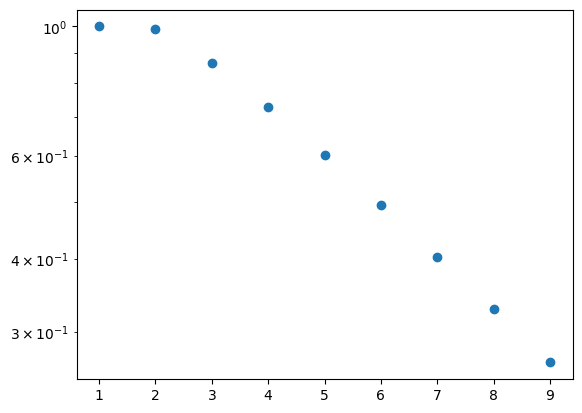

In [351]:
scatter(n_values,dat[:,0]/dat[0,0])
yscale("log")
print(dat[:,0]/dat[0,0])


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22613/2900733388.py:2: RuntimeWarning: divide by zero encountered in power
  plot(r,(dat[m,0]*r**(dat[m,1])/correlator_data.T[:,m])**(-1.))


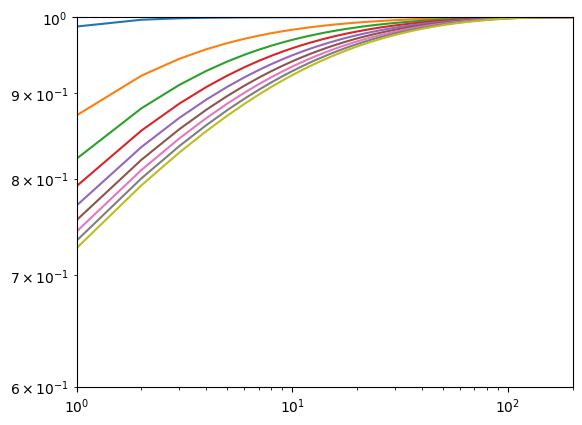

In [320]:
for m in range(len(n_values)):
    plot(r,(dat[m,0]*r**(dat[m,1])/correlator_data.T[:,m])**(-1.))
   # scatter(r,correlator_data.T[:,m],s=5)
    loglog()
    xlim(1,200)
    ylim(.6,1)


ValueError: operands could not be broadcast together with shapes (200,) (9,) 

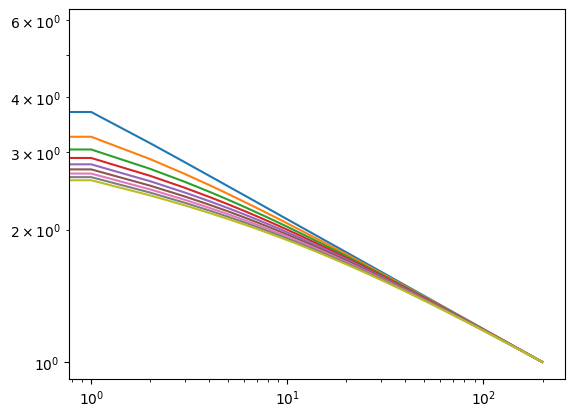

In [ ]:
dat=np.array(dat)

loglog(r,correlator_data.T/correlator_data.T[-1,:],label= label_list)
dat2 
loglog(r,dat[:,0]*r**(dat[:,1]))
xlim([1,200])
#ylim([0.01,.5])
plt.title(r"$\langle \psi_0 |P_n(0) P_n(r)| \psi_0  \rangle_{cc}$ with $h = 1$"
)
plt.xlabel(r"Distance $r$")
plt.ylabel(r"Expectation Value")

legend()


In [445]:
dat=[]
for n in range(2,8):
    ratios = correlator_data[0][180:] / correlator_data[n-1][180:]
    alpha_vals = np.log(ratios) / np.log(n)
    alpha = np.mean(alpha_vals)
    dat += [alpha]


[-0.00209098  0.16125535  1.        ]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_21485/1351887933.py:15: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(linear_model, r[start_from:], x)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_21485/1351887933.py:13: RuntimeWarning: divide by zero encountered in divide
  return a /(x**(2))+b/(x**(1/4))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_21485/1351887933.py:13: RuntimeWarning: invalid value encountered in add
  return a /(x**(2))+b/(x**(1/4))


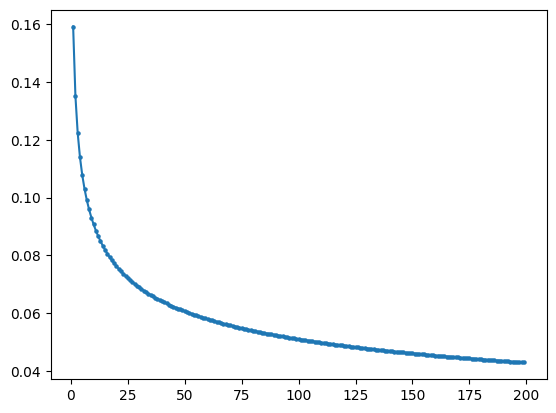

[-0.02232046  0.15983083  1.        ]


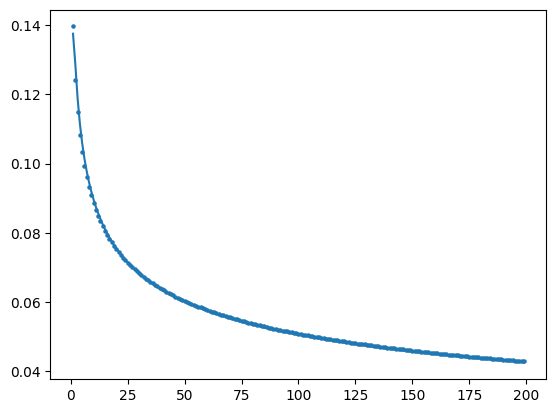

[-0.02786217  0.13940798  1.        ]


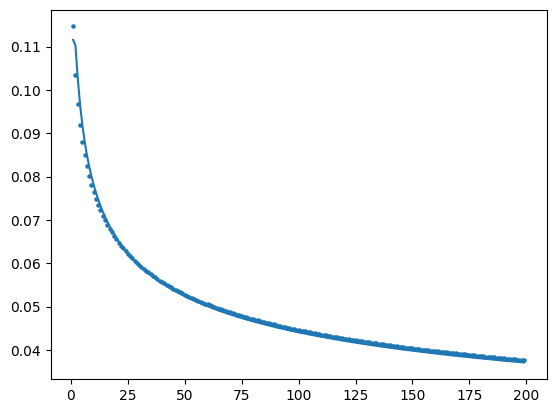

[-0.02794728  0.11741924  1.        ]


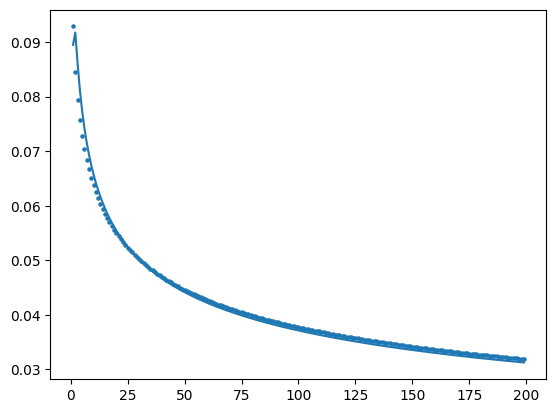

[-0.02584797  0.09739165  1.        ]


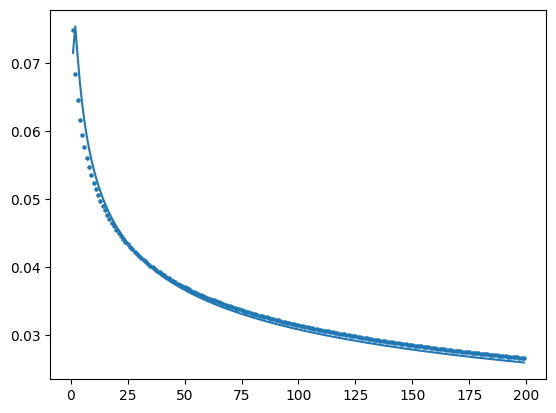

[-0.02294875  0.08010253  1.        ]


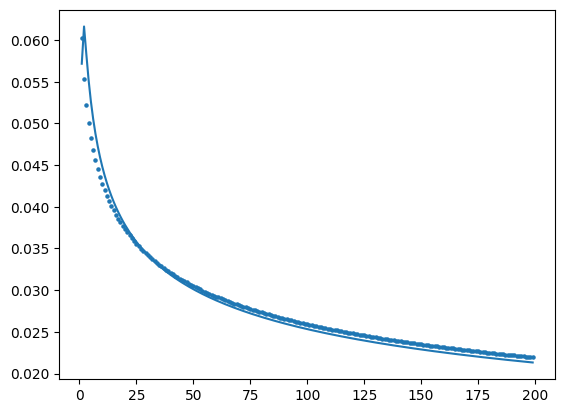

[-0.01988925  0.06553763  1.        ]


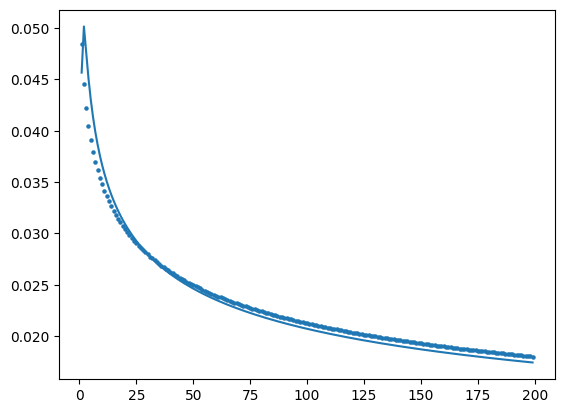

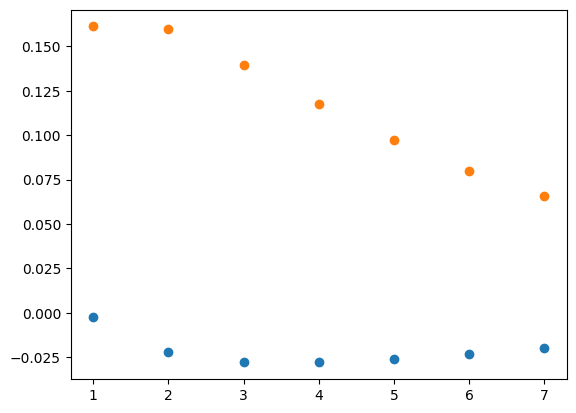

In [ ]:
from scipy.optimize import curve_fit
import numpy as np
As=[]
Bs=[]
for i in range(0,7):
    start_from  = 1

    dat[0]= 0
    x = correlator_data[i][start_from:]
    #r # your 1D data array of length 7

    def linear_model(x, a, b):
        return a /(x**(2))+b/(x**(1/4))

    params, _ = curve_fit(linear_model, r[start_from:], x)
    a, b,c = params
    print(params)
    plot(r[start_from:],linear_model(r,a,b)[start_from:])
    scatter(r[start_from:],x,s=5)
    As.append(params[0])
    Bs.append(params[1])

    plt.show()
plt.scatter([1,2,3,4,5,6,7],As)
plt.scatter([1,2,3,4,5,6,7],Bs)

0.25801227546559596
0.6366197723675814


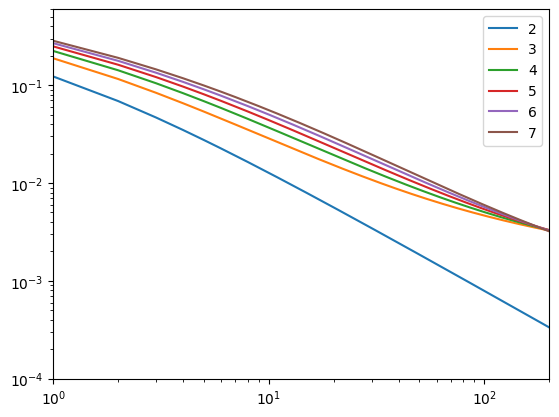

In [791]:
x = 0.6366197723675814
y = 0.5403796460924681

print(x*x*x)
print(x)
A1 = x   /4**1
A2 = 4*x/4**2
A3 = 14.2*x/4**3
A4 = 48.11*x/4**4
A5 = 160.39*x/4**5
A6 = 529.86*x/4**6
A7 = 1740.58*x/4**7

the_truth = correlator_data[0]/A1
#plot(r,abs(correlator_data[0]/A1),color="black")
plot(r,abs(correlator_data[1]/A2-the_truth),label="2")

plot(r,abs(correlator_data[2]/A3-the_truth),label="3")

plot(r,abs(correlator_data[3]/A4-the_truth),label="4")
plot(r,abs(correlator_data[4]/A5-the_truth),label="5")
plot(r,abs(correlator_data[5]/A6-the_truth),label="6")
plot(r,abs(correlator_data[6]/A7-the_truth),label="7")


#plt.scatter(r,r**(-1.),s=5)
#plt.scatter(r,r**(-2.),s=5)

plt.legend()
plt.xlim(1,200)
plt.ylim(0.0001,.6)
plt.xscale("log")
plt.yscale("log")

0.25801227546559596
0.6366197723675814


Text(0.5, 0, 'Distance $r$')

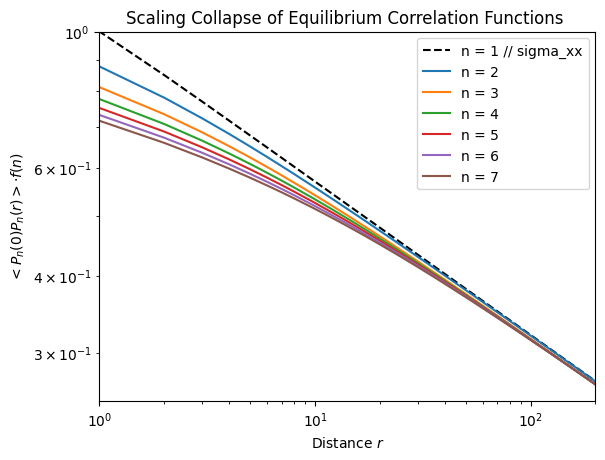

In [855]:
x = 0.6366197723675814
y = 0.5403796460924681

print(x*x*x)
print(x)
A1 = x   /4**1
A2 = 4*x/4**2
A3 = 14.2*x/4**3
A4 = 48.11*x/4**4
A5 = 160.39*x/4**5
A6 = 529.86*x/4**6
A7 = 1740.58*x/4**7

the_truth = correlator_data[0]/A1
plot(r,abs(correlator_data[0]/A1),linestyle="--",color="black",label="n = 1 // sigma_xx")
plot(r,abs(correlator_data[1]/A2),label="n = 2")

plot(r,abs(correlator_data[2]/A3),label="n = 3")

plot(r,abs(correlator_data[3]/A4),label="n = 4")
plot(r,abs(correlator_data[4]/A5),label="n = 5")
plot(r,abs(correlator_data[5]/A6),label="n = 6")
plot(r,abs(correlator_data[6]/A7),label="n = 7")


#plt.scatter(r,r**(-1.),s=5)
#plt.scatter(r,r**(-2.),s=5)

plt.legend()
plt.xlim(1,200)
plt.ylim(0.25,1)
plt.xscale("log")
plt.yscale("log")
plt.title("Scaling Collapse of Equilibrium Correlation Functions ")
plt.ylabel(r"$<P_n(0)P_n(r)> \cdot f(n)$")
plt.xlabel(r"Distance $r$")

Text(0.5, 0, 'Distance $r$')

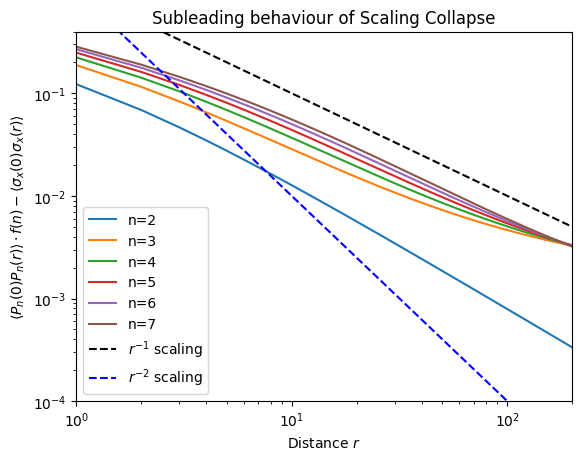

In [852]:

A1 = x/4**1
A2 = 4*x/4**2
A3 = 14.2*x/4**3
A4 = 48.11*x/4**4
A5 = 160.39*x/4**5
A6 = 529.86*x/4**6
A7 = 1740.58*x/4**7

the_truth = correlator_data[0]/A1

#plot(r[1:],abs(correlator_data[0]/A1-the_truth)[1:],color="black",label="n=1 //sigma_xx")
plot(r[1:],abs(correlator_data[1]/A2-the_truth)[1:],label="n=2")

plot(r[1:],abs(correlator_data[2]/A3-the_truth)[1:],label="n=3")

plot(r[1:],abs(correlator_data[3]/A4-the_truth)[1:],label="n=4")
plot(r[1:],abs(correlator_data[4]/A5-the_truth)[1:],label="n=5")
plot(r[1:],abs(correlator_data[5]/A6-the_truth)[1:],label="n=6")
plot(r[1:],abs(correlator_data[6]/A7-the_truth)[1:],label="n=7")

plot(r[1:],r[1:]**(-1.),color="black",linestyle="--",label=r"$r^{-1}$ scaling")
plot(r[1:],r[1:]**(-2.),color="blue",linestyle="--",label=r"$r^{-2}$ scaling")

plt.legend()
plt.xlim(1,200)
plt.ylim(0.0001,0.4)
plt.xscale("log")

plt.xscale("log")
plt.yscale("log")
plt.title("Subleading behaviour of Scaling Collapse")
plt.ylabel(r"$\langle P_n(0)P_n(r) \rangle \cdot f(n) - \langle \sigma_x(0) \sigma_x(r) \rangle$")
plt.xlabel(r"Distance $r$")

$\frac{A}{r^{1/4}}+ \frac{B}{r^{2}}$


$\frac{A}{B}$



Text(0.5, 0, 'Distance $r$')

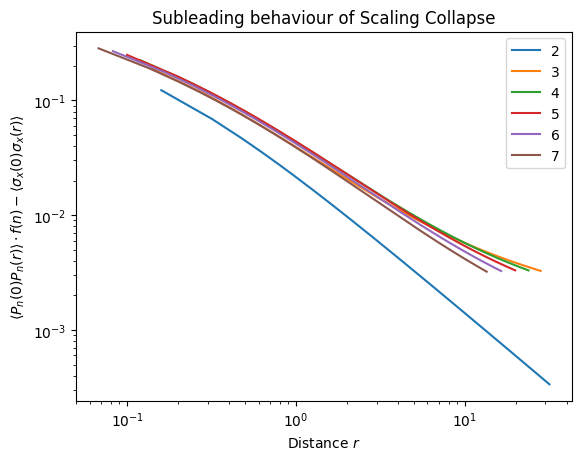

In [824]:

A1 = x/4**1
A2 = 4*x/4**2
A3 = 14.2*x/4**3
A4 = 48.11*x/4**4
A5 = 160.39*x/4**5
A6 = 529.86*x/4**6
A7 = 1740.58*x/4**7

the_truth = correlator_data[0]/A1

plot(r[1:]*A1,abs(correlator_data[0]/A1-the_truth)[1:],color="black")
plot(r[1:]*A2,abs(correlator_data[1]/A2-the_truth)[1:],label="2")

plot(r[1:]*A3,abs(correlator_data[2]/A3-the_truth)[1:],label="3")

plot(r[1:]*A4,abs(correlator_data[3]/A4-the_truth)[1:],label="4")
plot(r[1:]*A5,abs(correlator_data[4]/A5-the_truth)[1:],label="5")
plot(r[1:]*A6,abs(correlator_data[5]/A6-the_truth)[1:],label="6")
plot(r[1:]*A7,abs(correlator_data[6]/A7-the_truth)[1:],label="7")

plt.legend()
#plt.xlim(1,200)
plt.xscale("log")
plt.yscale("log")

plt.xscale("log")
#plt.yscale("log")
plt.title("Subleading behaviour of Scaling Collapse")
plt.ylabel(r"$\langle P_n(0)P_n(r) \rangle \cdot f(n) - \langle \sigma_x(0) \sigma_x(r) \rangle$")
plt.xlabel(r"Distance $r$")

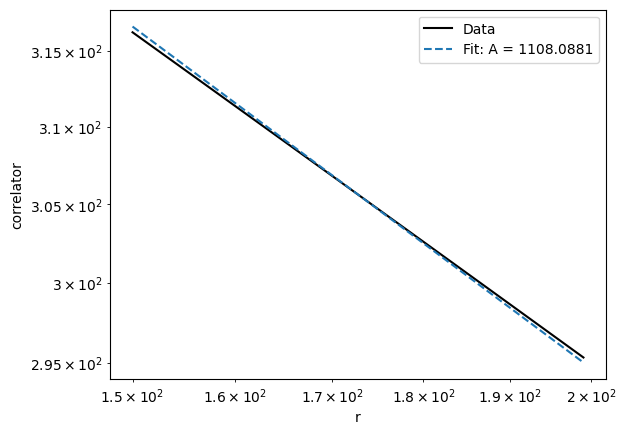

In [754]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# Define model: A / r^{1/4}
def power_law_model(r, A):
    return A/ (r ** 0.25)

# Example: fit to correlator_data[0]
r_fit = r[150:]  # r values (assume 1D array)
i = 6
n = i+1
y_fit = correlator_data[i][150:]*4**n # corresponding data

# Fit
params, _ = curve_fit(power_law_model, r_fit, y_fit)
A_fit = params[0]

# Plot
plt.plot(r_fit, y_fit, label="Data", color="black")
plt.plot(r_fit, power_law_model(r_fit, A_fit), '--', label=f"Fit: A = {A_fit:.4f}")

plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("r")
plt.ylabel("correlator")
plt.show()


In [ ]:


print(x*x*x)
print(x)
A1 = x   /4**1
A2 = 4*x/4**2
A3 = 14.2*x/4**3
A4 = 48.11*x/4**4
A5 = 160.39*x/4**5
A6 = 529.86*x/4**6
A7 = 1740.58*x/4**7

the_truth = correlator_data[0]/A1
plot(r,abs(correlator_data[0]/A1),linestyle="--",color="black",label="n = 1 // sigma_xx")
plot(r,abs(correlator_data[1]/A2),label="n = 2")

plot(r,abs(correlator_data[2]/A3),label="n = 3")

plot(r,abs(correlator_data[3]/A4),label="n = 4")
plot(r,abs(correlator_data[4]/A5),label="n = 5")
plot(r,abs(correlator_data[5]/A6),label="n = 6")
plot(r,abs(correlator_data[6]/A7),label="n = 7")


#plt.scatter(r,r**(-1.),s=5)
#plt.scatter(r,r**(-2.),s=5)

plt.legend()
plt.xlim(150,200)
plt.ylim(0.25,1)
plt.xscale("log")
plt.yscale("log")
plt.title("Scaling Collapse of Equilibrium Correlation Functions ")

4.504504504504505

In [856]:
xi

NameError: name 'xi' is not defined

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22613/3529890228.py:1: RuntimeWarning: divide by zero encountered in power
  plot(r,r**(-1/4))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22613/3529890228.py:3: RuntimeWarning: divide by zero encountered in power
  plot(r,1*r**(-1/4)+r**(-2.))


[]

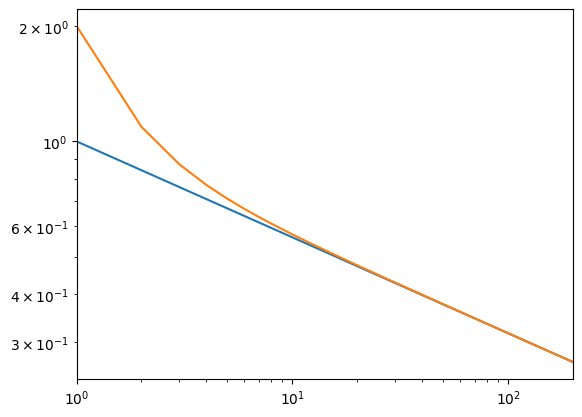

In [407]:
plot(r,r**(-1/4))
#plot(r,r**(-2.))
plot(r,1*r**(-1/4)+r**(-2.))
xlim(1,r[-1])
loglog()